In [2]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Homework \#3


In this homework, you will get to practice the computation of maximum likelihood estimates and Gaussian mixture models.

## Problem 1: MLE for Laplace Distribution

You are given 10 points $\{ 0.19529091,  0.93106584,  0.15147936, -0.43860253,  0.15290169, -1.18712532, -0.2587244 , -1.67139275, -0.55631196, -2.11156991\}$ that were drawn i.i.d. from Laplace distribution with scale 1, which has the probability density function $f(x|\theta) = \frac{1}{2}e^{-|x - \theta|},$ where $\theta$ is the unknown parameter you want to estimate. What are the likelihood and the log-likelihood functions for this problem? Can you use the derivative test to obtain a maximum likelihood estimate for $\theta$? 
       
Using the data provided in the paragraph above, plot the log-likelihood function and deduce the MLE of $\theta.$ Is MLE unique for this problem?

The likelihood function is $f(x|\theta) = \prod_{i=1}^{10} \frac{1}{2}e^{-|x_i-\theta|} = (\frac{1}{2})^{10}e^{\sum_{i=1}^{10}-|x_i - \theta|}$ so the log likelihood is $log(f(x|\theta)) = -10log(2)-\sum_{i=1}^{10}|x_i-\theta|$. Notice $|x_i -\theta|$ isn't differentiable when $x_i = \theta$ so the standard derivative test won't work here. Also the MLE is not unique since the peak (derivative = 0) lies between the 5th and 6th points and so any $\theta$ in that range qualifies as a MLE.

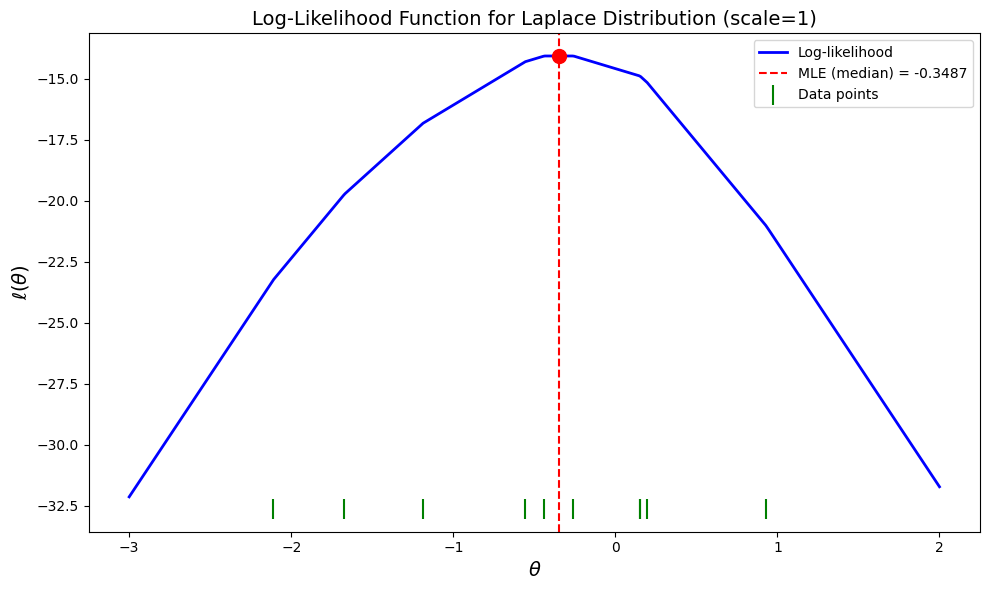

In [3]:
data = np.array([0.19529091,  0.93106584,  0.15147936, -0.43860253,  0.15290169, -1.18712532, -0.2587244 , -1.67139275, -0.55631196, -2.11156991])

def log_likelihood(theta, x):
    return -len(x) * np.log(2) - np.sum(np.abs(x - theta))

theta_vals = np.linspace(-3, 2, 500)
ll_vals = []

for theta in theta_vals:
    ll_vals.append(log_likelihood(theta,data))
 
# MLE is the median
mle = np.median(data)
ll_at_mle = log_likelihood(mle, data)
 
plt.figure(figsize=(10, 6))
plt.plot(theta_vals, ll_vals, 'b-', linewidth=2, label='Log-likelihood')
plt.axvline(mle, color='r', linestyle='--', linewidth=1.5, label=f'MLE (median) = {mle:.4f}')
plt.scatter([mle], [ll_at_mle], color='r', s=100, zorder=5)
 
# plot data points on x-axis
plt.scatter(data, [min(ll_vals) - 0.5] * len(data), color='green', marker='|', s=200, label='Data points')
 
plt.xlabel(r'$\theta$', fontsize=14)
plt.ylabel(r'$\ell(\theta)$', fontsize=14)
plt.title('Log-Likelihood Function for Laplace Distribution (scale=1)', fontsize=14)
plt.legend()
plt.tight_layout()
 
plt.show()


## Problem 2: MLE for Poisson Distribution

The following points have been drawn from Poisson distribution with the unknown parameter $\lambda:$ $\{4, 5, 3, 2, 4, 7, 5, 5, 2, 2\}.$ (Recall that for the Poisson distribution, $\mathbb{P}[X = k] = \frac{\lambda^k e^{-\lambda}}{k!}$ for $k \geq 0$.) What is the log-likelihood function for estimating $\lambda$?

1. Compute the MLE of $\lambda.$
2. Suppose that we know that $\lambda \geq 4.5.$ Find the MLE of $\lambda.$
3. Suppose that we know that $\lambda$ is an integer. Find the MLE of $\lambda.$ 

1. The likelihood function is $f(\lambda) = \prod_{j=1}^{10} \frac{e^{-\lambda}\lambda^{x_j}}{x_j !}$ and the log-likelihood function is 
$log(f(\lambda)) = \sum_{j=1}^{10}log(\frac{e^{-\lambda}\lambda^{x_j}}{x_j!} = \sum_{j=1}^{10}-\lambda-log(x_j!)+x_jlog(\lambda)$. Since the sum of the drawn data is 39 then $g(\lambda) = log(f(\lambda)) = 39log(\lambda) - 10\lambda - \sum_{j=1}^{10}log(x_j!)$. Then 
$$g'(\lambda) = \frac{39}{\lambda} - 10 = 0$$ for $\hat{\lambda} = 3.9$.
2. For $\lambda \geq 4.5$, let $\lambda = max(\hat{\lambda}, 4.5) = 4.5$ since the log-likelihood is concave peaking at 3.9.
3. If $\lambda \in \mathbb{Z}$ then round $\hat{\lambda} = 4$ from 3.9 since $g(4) \approx 39log(4) - 40 = 14.06$ and $g(3) \approx 39log(3) - 30 = 12.86$ so 4 is better.

## Problem 3: Empirical Distribution as MLE

Suppose you are given $n > 10$ data points drawn i.i.d. from some unknown distribution and that take values from the set $\{1, 2, \dots, 10\}.$ Show that the empirical distribution of your data sample is the MLE for individual probabilities of the points from the set $\{1, 2, \dots, 10\}.$

For each $i \in \{1,2,\cdots, 10\}$ let $n_i$ be the frequency of each $i$ occurring in $n$ iid drawn data points. Thus $p_i = \frac{n_i}{n}$ so $\sum_{i=1}^{10}p_i = 1$ or, equivalently, $p_i = 1 - \sum_{j=1}^{i-1}p_j$. Then let $f(p_1, p_2,\cdots p_{10}) = \prod_{i=1}^{10} p_i^{n_i}$ since the data is iid. Then the log-likelihood is $l = n_1log(p_1) + n_2log(p_2) + \cdots n_{10}log(1 - p_1 - p_2 - \cdots -p_9)$ so for any index $1 \leq i \leq 9$, 
$\frac{\partial l}{\partial p_i} = \frac{n_i}{p_i} - \frac{n_{10}}{p_{10}} = 0$ gives $\frac{n_i}{p_i} = \frac{n_{10}}{p_{10}}$. In other words the empirical probability and individual probability of an arbitrary point (MLE param $p_i$) are the same so the empirical distribution implies the MLE for point probabilities.

## Problem 4 [Coding]: Gaussian Mixture Model

1. Implement a function in Python that takes the array `n_samples` of the number of the samples per cluster, the dimension `d` of the samples and the array `mu` of the means of the Gaussians as input, and returns the samples and their cluster membership labels drawn from the mixture of spherical Gaussians (with the identity covariance).

**Hint:** Use the function `sklearn.datasets.make_blobs`.

In [9]:
def Data_Generator(n_samples, d, mu):
    '''
    Parameters
    ----------
    n_samples: 1-D array-like
        Numeber of the samples per cluster.
    d: int
        Dimension of the sample
    mu: 2-D array-like (number of clusters, d)
        Means of the Gaussians in the mixture

    Returns
    -------
    X: 2-D array-like (n_samples, d)
        Samples generated from the Gaussian mixture
    Y: 1-D array-like
        Integer labels for cluster membership of each sample
    '''
    X, Y = make_blobs(n_samples=n_samples, n_features=d, centers=mu, cluster_std=1.0)
    return X, Y
    

2. Implement a function in Python using the Gaussian mixture model that fits the data generated by `Data_Generator`, and returns the fitted model and the estimated weights of the mixture.

**Hint:** Use the function `sklearn.mixture.GaussianMixture`.

In [8]:
def fit(X, n_components):
    '''
    Parameters
    ----------
    X: 2-D array-like (n_samples, d)
        Samples generated from the Gaussian mixture

    Returns
    -------
    model: 
        Gaussian mixture model fitted on the data X
    weights: 1-D array-like
        Weights of the mixture
    '''
    model = GaussianMixture(n_components=n_components)
    model.fit(X)
    weights = model.weights_
    return model, weights
    

3. Use `Data_Generator` and `fit` to generate the data and fit a Gaussian mixture model based on the following parameter. Plot the clusters according to the true labels and the predicted labels in two figures.

**Hint:** Use the function `plt.scatter` for your plots.

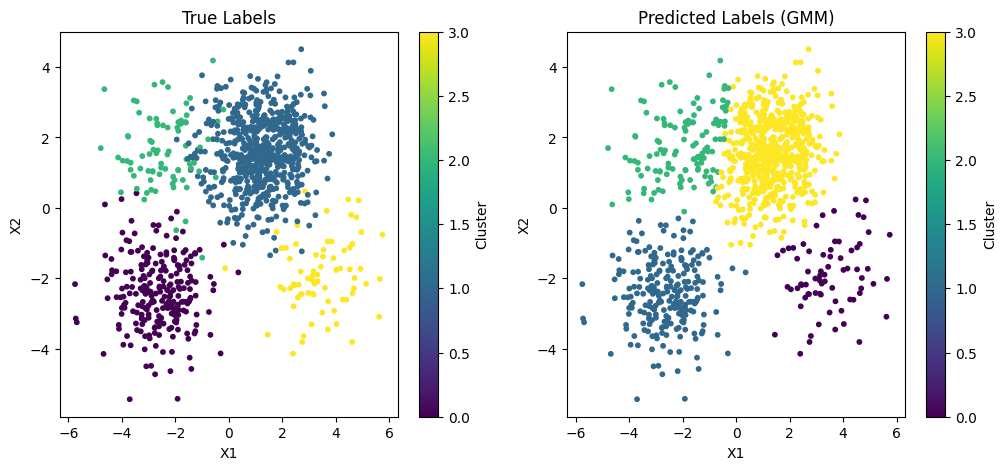

In [10]:
n_samples = np.array([240, 610, 80, 70])
d = 2
mu = np.array([[-2.6, -2.4], [1.2, 1.6], [-2.3, 1.8], [3.5, -1.9]])
X, Y = Data_Generator(n_samples, d, mu)

# gmm 
n_components = len(mu)
model, weights = fit(X, n_components)

# predict cluster labels
Y_pred = model.predict(X)

# plot true labels
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', s=10)
plt.title('True Labels')
plt.xlabel('X1')
plt.ylabel('X2')
plt.colorbar(label='Cluster')

# Plot predicted labels
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=Y_pred, cmap='viridis', s=10)
plt.title('Predicted Labels (GMM)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.colorbar(label='Cluster')

plt.show()
